CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64
Mean Squared Error (Training): 19.326470203585725
Mean Squared Error (Testing): 33.44897999767657
R-Squared (Training): 0.7730135569264234
R-Squared (Testing): 0.5892223849182503


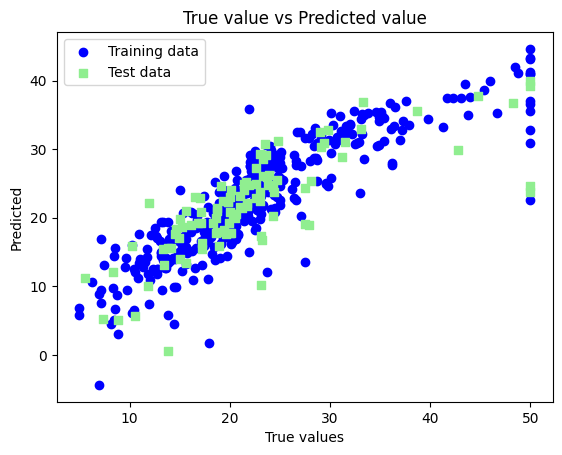

In [5]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2-5: Import the Boston Housing dataset from the original source
data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Formatting the data as per scikit-learn's requirement
# Features are in every even row and the first two columns of odd rows
X_data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
# Target (PRICE) is the third column of every odd row
y_target = raw_df.values[1::2, 2]

# Initialize the dataframe and add feature names
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
data = pd.DataFrame(X_data, columns=feature_names)
data['PRICE'] = y_target

# 1. Load the dataset provided by the college
# Change 'Boston.csv' to the exact name of the file provided to you
# df = pd.read_csv('Boston.csv')
# df.head()

# Step 6: Check for missing values (Optional to print)
print(data.isnull().sum())

# Step 7: Split dependent variable (y) and independent variables (x)
x = data.drop(['PRICE'], axis=1)
y = data['PRICE']

# Step 8: Splitting data into training and testing datasets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=0)

# Step 9: Use linear regression to create and train the model
lm = LinearRegression()
model = lm.fit(xtrain, ytrain)

# Step 10: Predict the values for train and test data
ytrain_pred = lm.predict(xtrain)
ytest_pred = lm.predict(xtest)

# Step 12: Calculate Mean Squared Error (MSE)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
print(f"Mean Squared Error (Training): {mse_train}")
print(f"Mean Squared Error (Testing): {mse_test}")

# Assignment Question 3: Calculate R-Square for Boston Dataset
r2_train = r2_score(ytrain, ytrain_pred)
r2_test = r2_score(ytest, ytest_pred)
print(f"R-Squared (Training): {r2_train}")
print(f"R-Squared (Testing): {r2_test}")

# Step 13: Plotting the linear regression model
plt.scatter(ytrain, ytrain_pred, c='blue', marker='o', label='Training data')
plt.scatter(ytest, ytest_pred, c='lightgreen', marker='s', label='Test data')
plt.xlabel('True values')
plt.ylabel('Predicted')
plt.title("True value vs Predicted value")
plt.legend(loc='upper left')
plt.show()